## covariance, correlation, scatter plot 

In [16]:
# _rd_01.py 
# 상관관계, 상관계수, 공분산, 산포도. 그룹, 히스토그램 등 회귀분석 전 설명.
# raw data - x: 키, y: 체중, n = 3111 
# mean function in regression. 작업예정... 

import os
import numpy as np                          # numpy 라이브러리 전체. 
import pandas as pd                         # pandas 라이브러리 전체, 시계열(기본) 여기 있네. 
import scipy as sci 
from scipy import stats, optimize, linalg   # scipy 라이브러리 하부 모듈. 필요한 통계 모듈만.
import statsmodels.api as sm                # 방대한 모델이라 개발자들이 많이 쓰는 모델 묶음.
from statsmodels.tsa import stattools       # time series analysis 
from statsmodels.tsa.arima.model import ARIMA # 이거 가능하다 이거지. 이거 대문자네. 꼭. 소문자 못읽어.
import matplotlib.pyplot as plt


In [17]:

# 데이터 파일 읽기. github.com
dat_url = 'https://github.com/bahn28/gamja/blob/main/cs_nns_hgt_wgt.xlsx?raw=true'
df_dat = pd.read_excel(dat_url) 
df_dat.head() 


,x,y
0,174.262367,70.149796
1,166.350641,60.169389
2,158.381596,63.394676
3,163.472285,46.948571
4,157.954485,49.428887


In [18]:

# 1. 데이터 준비. 읽기. 생성. 
#   데이터 읽고 처리 단계.
#   dat을 한 번에 읽었다, 3개 변수로 지정. dat은 data frame 형식.
n_obs = len(df_dat) 
hgt = df_dat['x'].to_numpy()
wgt = df_dat['y'].to_numpy()
#    gndr = (gndrlit == 'Male').astype(int)   # astype(int)으로 NumPy 배열 전환, 1/0  


# 2. 자료 검토, 요약, 그래프 생성.
# 2a. 자료 검토, 기초 통계량
summ = df_dat.agg(
            ["count", "mean", "std", "min", "median", "max"]
            ) # 일부 변수, 일부 통계량 
# print(summ)
summ.head()


,x,y
count,3111.000000,3111.000000
mean,167.076163,63.463587
std,8.599366,12.642302
min,138.146769,20.077826
median,167.040445,63.680696


\begin{align}
 Cov(x,y) & = {\sum (x_i - \bar x)(y_i - \bar y)} \\
 \rho_{x,y} & = {Cov(x,y) \over \sigma_x \sigma_y}
 \end{align}

$$ \left[
\begin{array} c  
 1 & \sigma_{x,y} \\
 \sigma_{y,x} & 1
\end{array}
\right]
$$

$$ \left[
\begin{array} c  
 1 & \rho_{x,y} \\
 \rho_{y,x} & 1
\end{array}
\right]
$$

In [19]:

# 2b. 상관계수, 공분산, 전체 
covmat = np.cov(wgt, hgt)
cov = covmat[0, 1]
rhomat = np.corrcoef(wgt, hgt)
rho = rhomat[0,1]
#    print( "covmat\n", covmat, "\nrhomat\n", rhomat)
print(f"covmat\n{covmat}\n\nrhomat\n{rhomat}") 


covmat
[[159.82780987  72.55380412]
 [ 72.55380412  73.94909679]]

rhomat
[[1.         0.66737138]
 [0.66737138 1.        ]]


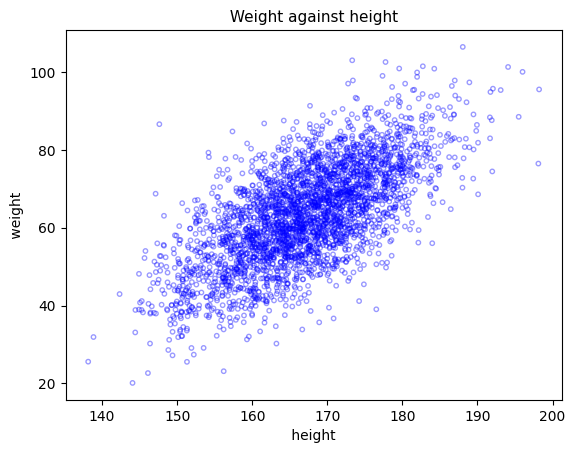

In [20]:

# 2c. 자료 검토, 시각화 확인.
# 산포도 ( x, y )  
plt.figsize=(10, 10)
plt.scatter(hgt, wgt, s=10, facecolor='none', edgecolor='blue', alpha=0.4)
plt.title(" Weight against height ", fontsize=11)
plt.xlabel(" height ")
plt.ylabel(" weight ")
plt.show()
